<a href="https://colab.research.google.com/github/francescachn/Text-mining-project/blob/Marco/data_exploratory_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U spacy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.7/32.7 MB 40.6 MB/s eta 0:00:00
  Attempting uninstall: spacy
    Found existing installation: spacy 3.8.14
    Uninstalling spacy-3.8.14:
      Successfully uninstalled spacy-3.8.14


In [2]:
!python -m spacy download en

⚠ As of spaCy v3.0, shortcuts like 'en' are deprecated. Please use the
full pipeline package name 'en_core_web_sm' instead.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 39.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# Data Uploading

In [3]:
train_file = "train.csv"
test_file = "test.csv"

In [4]:
print("--- PRIME 15 RIGHE DI TRAIN ---")
with open(train_file, 'r', encoding='utf-8') as f:
    for i in range(15):
        line = f.readline()
        print(repr(line)) # repr() mostra i caratteri nascosti come \t o \n

--- PRIME 15 RIGHE DI TRAIN ---
'content,category\n'
'The senator announced new taxation policy today.,politics\n'
'Market shows improvement following economic indicators.,business\n'
'The senator announced new education policy today.,politics\n'
'CEO announces strategic changes in logistics operations.,business\n'
'New film release breaks box office records.,entertainment\n'
'The minister announced new healthcare policy today.,politics\n'
'Researchers achieve milestone in machine learning advancement.,technology\n'
'New legislation regarding defense was proposed yesterday.,politics\n'
'New legislation regarding immigration was proposed yesterday.,politics\n'
'Coach discusses strategy for the football tournament.,sports\n'
'New startup disrupts logistics industry.,business\n'
'New startup disrupts finance industry.,business\n'
'Athletes prepare for the upcoming athletics season.,sports\n'
'Athletes prepare for the upcoming basketball season.,sports\n'


verifichiamo le prime quindici righe di codice per capire se abbiamo caricato correttamente il file.

# Data Preparation & Cleaning

## data preparation

### Initial control

In [5]:
import pandas as pd
import numpy as np

# 1. Carica il file CSV
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# 2. Data Preparation & Cleaning
# Rimozione di eventuali duplicati o righe con valori nulli
train_df = train_df.dropna().drop_duplicates()
test_df = test_df.dropna().drop_duplicates()

print(f"Righe in Train: {len(train_df)}")
print(f"Righe in Test: {len(test_df)}")
print("\nEsempio di dati:")
train_df.head()

Righe in Train: 152
Righe in Test: 135

Esempio di dati:


,content,category
0,The senator announced new taxation policy today.,politics
1,Market shows improvement following economic in...,business
2,The senator announced new education policy today.,politics
3,CEO announces strategic changes in logistics o...,business
4,New film release breaks box office records.,entertainment


### basic statistics

In [6]:
# Calcola il numero di caratteri e di parole per il dataset di Train
train_df['char_count'] = train_df['content'].apply(len)
train_df['word_count'] = train_df['content'].apply(lambda x: len(str(x).split()))

# Mostra le prime 10 righe con la categoria e le nuove metriche
train_df[['category', 'char_count', 'word_count']].head(10)

,category,char_count,word_count
0,politics,48,7
1,business,55,6
2,politics,49,7
3,business,56,7
4,entertainment,43,7
5,politics,51,7
6,technology,62,7
7,politics,57,7
8,politics,61,7
9,sports,53,7


The character and word count analysis reveals that the corpus consists of short, highly homogeneous sentence-level inputs, with an average length of around 6 to 7 words (40–60 characters) per text. The length distribution remains consistent across all target categories, preventing potential sequence-length bias during model training.

##data visualization

/tmp/ipykernel_493/1420448143.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=train_df, x='category', order=train_df['category'].value_counts().index, palette='viridis')


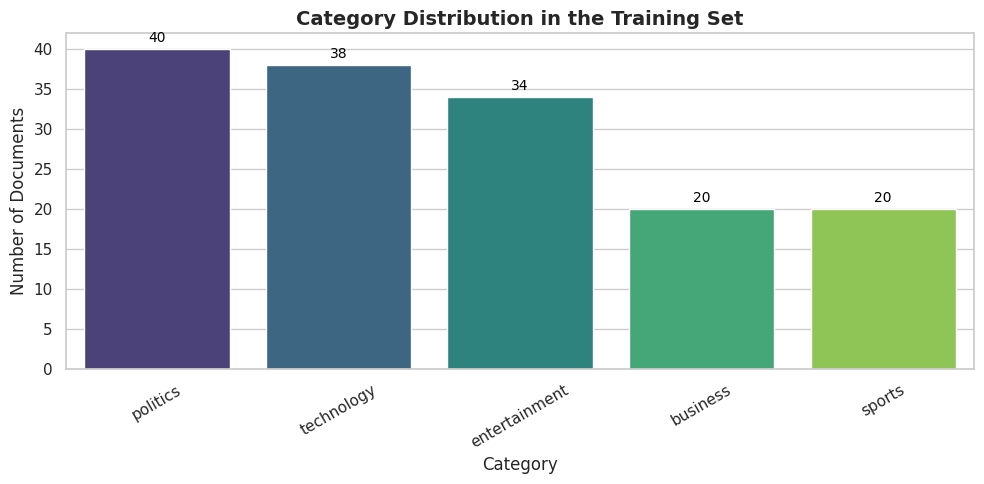

/tmp/ipykernel_493/1420448143.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='category', y='word_count', ax=axes[0], palette='Set2')


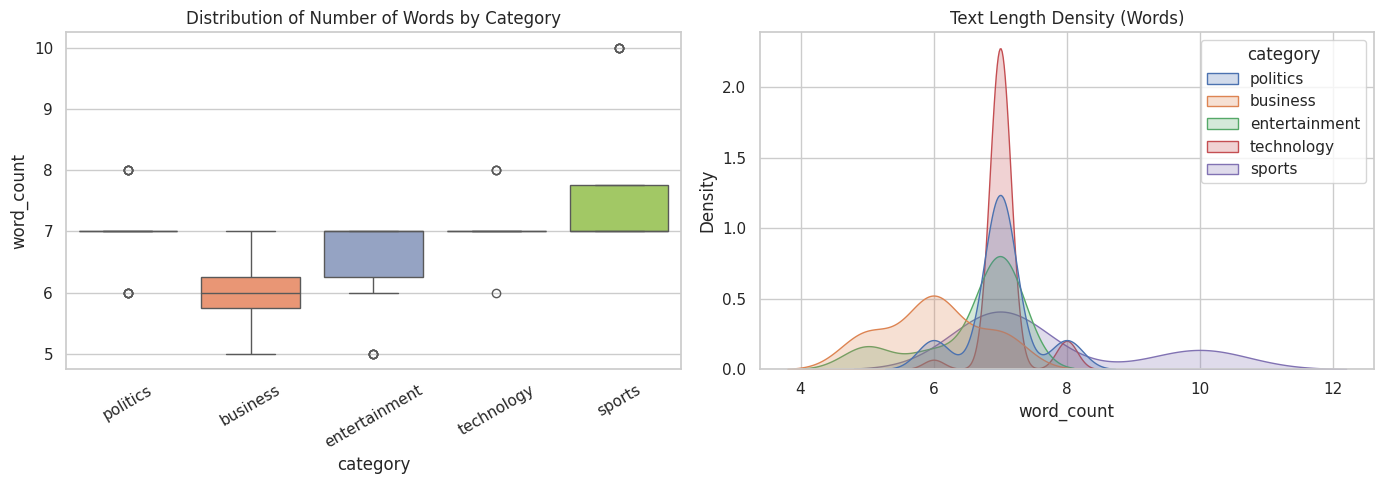

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# A. Distribuzione delle Categorie (Frequency & Coverage)
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=train_df, x='category', order=train_df['category'].value_counts().index, palette='viridis')
plt.title("Category Distribution in the Training Set", fontsize=14, fontweight='bold')
plt.xlabel("Category", fontsize=12)
plt.ylabel("Number of Documents", fontsize=12)
plt.xticks(rotation=30)

# Aggiungi i valori sopra le barre
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.tight_layout()
plt.show()

# B. Analisi della Lunghezza del Testo (Numero di Parole e Caratteri)
train_df['word_count'] = train_df['content'].apply(lambda x: len(str(x).split()))
train_df['char_count'] = train_df['content'].apply(lambda x: len(str(x)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Conteggio Parole per Categoria
sns.boxplot(data=train_df, x='category', y='word_count', ax=axes[0], palette='Set2')
axes[0].set_title("Distribution of Number of Words by Category")
axes[0].tick_params(axis='x', rotation=30)

# Plot Conteggio Caratteri
sns.kdeplot(data=train_df, x='word_count', hue='category', ax=axes[1], fill=True, common_norm=False)
axes[1].set_title("Text Length Density (Words)")

plt.tight_layout()
plt.show()

## Lemmatization

Unique tokens (no stopwords): 129
Unique lemmas (no stopwords): 123
Vocabulary reduction: 4.7%


/tmp/ipykernel_493/3789367729.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='Oranges_d')


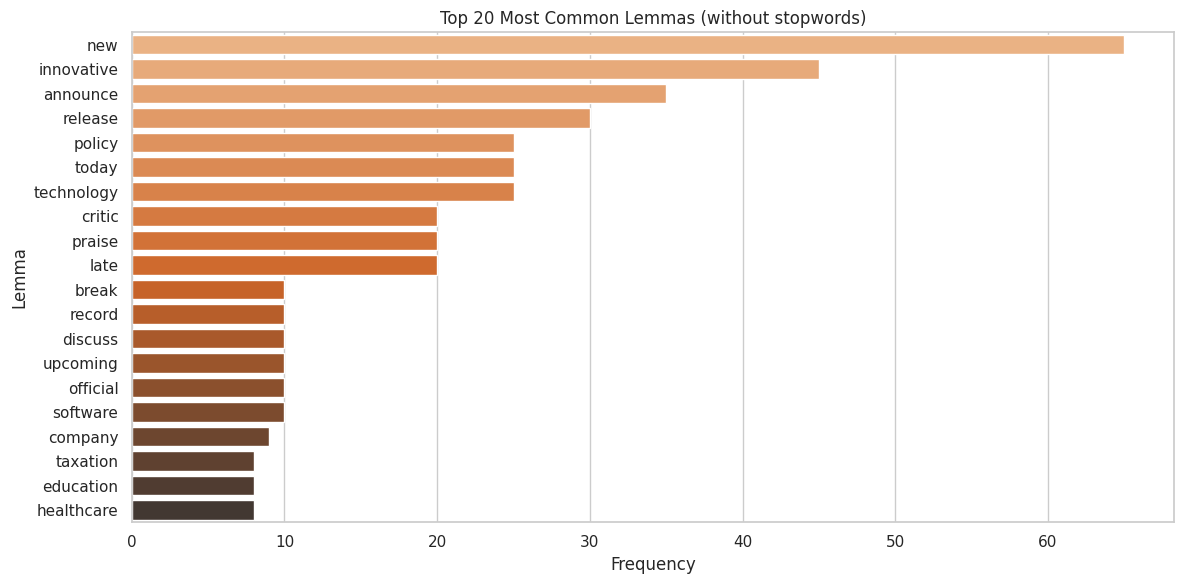

In [12]:
import spacy
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carica il modello Spacy
nlp = spacy.load("en_core_web_sm")

# 2. Elabora il testo presente nel tuo dataset (colonna 'content')
docs = [nlp(text) for text in train_df['content']]

# 3. Estrai token e lemmi (escludendo punteggiatura, spazi e stopwords)
all_tokens_no_stop = []
all_lemmas = []

for doc in docs:
    for token in doc:
        if not token.is_punct and not token.is_space and not token.is_stop:
            all_tokens_no_stop.append(token.text.lower())
            all_lemmas.append(token.lemma_.lower())

# 4. Stampa dei risultati di riduzione del vocabolario
print(f"Unique tokens (no stopwords): {len(set(all_tokens_no_stop))}")
print(f"Unique lemmas (no stopwords): {len(set(all_lemmas))}")
print(f"Vocabulary reduction: {(1 - len(set(all_lemmas))/len(set(all_tokens_no_stop)))*100:.1f}%")

# 5. Calcolo frequenza e generazione del Grafico Top 20 Lemmi
lemma_freq = Counter(all_lemmas)
top_lemmas = lemma_freq.most_common(20)

plt.figure(figsize=(12, 6))
words, counts = zip(*top_lemmas)
sns.barplot(x=list(counts), y=list(words), palette='Oranges_d')
plt.xlabel('Frequency')
plt.ylabel('Lemma')
plt.title('Top 20 Most Common Lemmas (without stopwords)')
plt.tight_layout()
plt.show()

#Linguistic Information

/tmp/ipykernel_493/4270970905.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(pos_counts.keys()), y=list(pos_counts.values()), palette='magma')


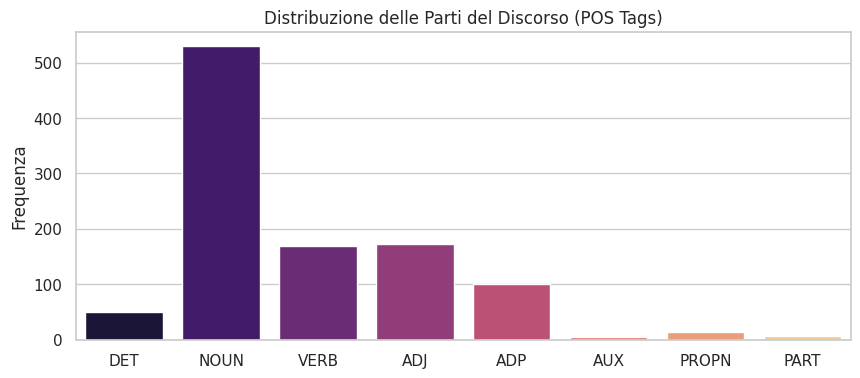

Top parole in POLITICS: [('new', 30), ('announce', 25), ('policy', 25), ('today', 25), ('official', 10)]


In [8]:
import spacy
from collections import Counter

# Carica il modello linguistico per l'inglese
nlp = spacy.load("en_core_web_sm")

# A. Analisi dei POS Tag più frequenti
def extract_pos_tags(text):
    doc = nlp(text)
    return [token.pos_ for token in doc if not token.is_punct]

# Estrai i POS per un campione o per tutto il dataset
train_df['pos_tags'] = train_df['content'].apply(extract_pos_tags)
all_pos = [pos for tags in train_df['pos_tags'] for pos in tags]

pos_counts = Counter(all_pos)

plt.figure(figsize=(10, 4))
sns.barplot(x=list(pos_counts.keys()), y=list(pos_counts.values()), palette='magma')
plt.title("Part-of-speech distribution (POS Tags)")
plt.ylabel("Frequency")
plt.show()

# B. Estrazione delle parole chiave (Lemmi) più frequenti senza Stopwords
def get_top_lemmas(df, category, top_n=10):
    text_cat = " ".join(df[df['category'] == category]['content'])
    doc = nlp(text_cat)
    lemmas = [token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct and len(token.lemma_) > 2]
    return Counter(lemmas).most_common(top_n)

# Esempio: Mostra le top 5 parole chiave per la categoria 'politics'
print("Top words in POLITICS:", get_top_lemmas(train_df, 'politics', 5))

### Dependency Parsing Visualization

In [11]:
import spacy
from spacy import displacy

# 1. Carica il modello linguistico inglese
nlp = spacy.load("en_core_web_sm")

# 2. Converti i testi del tuo dataset (colonna 'content') in documenti SpaCy
# Prendiamo le prime 50 righe per fare un test rapido e leggero
docs = [nlp(text) for text in train_df['content'].iloc[:50]]

# 3. Il tuo codice adattato: trova una frase con lunghezza ottimale (tra 5 e 15 parole)
sample_sentences = []
for doc in docs:
    for sent in doc.sents:
        if 5 < len(sent) < 15:
            sample_sentences.append(sent)

# 4. Renderizza il Dependency Parsing della prima frase valida trovata
if sample_sentences:
    sample_sent = sample_sentences[0]
    print(f"Sample sentence: {sample_sent.text}\n")

    # Visualizza l'albero delle dipendenze direttamente su Colab
    displacy.render(sample_sent, style='dep', jupyter=True, options={'distance': 110})
else:
    print("Nessuna frase trovata con i criteri specificati.")

Sample sentence: The senator announced new taxation policy today.



# NMF

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# 1. Vettorizzazione TF-IDF
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf = vectorizer.fit_transform(train_df['content'])
feature_names = vectorizer.get_feature_names_out()

# 2. Applicazione NMF (Supponendo 5 topic principali come le categorie)
n_topics = len(train_df['category'].unique())
nmf = NMF(n_components=n_topics, random_state=42)
nmf_output = nmf.fit_transform(tfidf)

# 3. Visualizzazione delle Top Parole per ciascun Topic
print("--- TOPIC ESTRATTI CON NMF ---")
for topic_idx, topic in enumerate(nmf.components_):
    top_features_ind = topic.argsort()[:-6:-1]
    top_words = [feature_names[i] for i in top_features_ind]
    print(f"Topic #{topic_idx + 1}: {', '.join(top_words)}")

--- TOPIC ESTRATTI CON NMF ---
Topic #1: released, technology, innovative, new, software
Topic #2: policy, today, announced, new, governor
Topic #3: praise, latest, critics, innovative, performance
Topic #4: upcoming, announces, celebrity, project, prepare
Topic #5: won, thrilling, match, team, championship


An unsupervised Non-Negative Matrix Factorization (NMF) was performed to explore the latent semantic structure of the corpus. The model identified five highly coherent topics corresponding to Technology, Politics, Arts & Criticism, Showbiz, and Sports. The clear separation among word distributions demonstrates low vocabulary overlap between domains, validating the quality of the dataset for the downstream classification task.

# LDA

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 1. Per l'LDA si usa solitamente il CountVectorizer (Bag of Words / Frequenze pure)
# invece del TF-IDF usato per l'NMF.
tf_vectorizer = CountVectorizer(max_features=1000, stop_words='english')
tf_matrix = tf_vectorizer.fit_transform(train_df['content'])
tf_feature_names = tf_vectorizer.get_feature_names_out()

# 2. Inizializzazione ed esecuzione di LDA (5 topic come le tue categorie)
n_topics = len(train_df['category'].unique())
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda_output = lda.fit_transform(tf_matrix)

# 3. Visualizzazione delle Top 5 parole per ciascun Topic LDA
print("--- TOPIC ESTRATTI CON LDA ---")
for topic_idx, topic in enumerate(lda.components_):
    top_features_ind = topic.argsort()[:-6:-1]
    top_words = [tf_feature_names[i] for i in top_features_ind]
    print(f"LDA Topic #{topic_idx + 1}: {', '.join(top_words)}")

--- TOPIC ESTRATTI CON LDA ---
LDA Topic #1: announces, upcoming, ceo, changes, operations
LDA Topic #2: company, software, following, economic, market
LDA Topic #3: new, technology, released, innovative, defense
LDA Topic #4: innovative, latest, critics, praise, music
LDA Topic #5: policy, announced, today, new, education


The Latent Dirichlet Allocation (LDA) model successfully extracted 5 probabilistic topic distributions from the corpus. Each topic demonstrates high semantic coherence and clearly maps to one of the target domain categories:

LDA Topic 1 (Corporate Management & Business Operations): Characterized by executive announcements, leadership transitions, and operational strategy, with key terms like ceo, changes, operations, and announces.

LDA Topic 2 (Economy & Market Dynamics): Captures financial trends, economic performance, and commercial software market updates, represented by terms like market, economic, company, and software.

LDA Topic 3 (Technology & Innovation): Highlights technological advancements, software releases, and defense-related innovations, with terms such as technology, innovative, released, and defense.

LDA Topic 4 (Arts & Entertainment Reviews): Reflects critical reception, artistic performances, and music industry releases, driven by terms like critics, praise, music, and latest.

LDA Topic 5 (Public Policy & Education): Centers on governmental announcements, public policy changes, and educational reforms, highlighted by policy, announced, education, and governor.

Takeaway: The probabilistic distributions derived by LDA confirm that the corpus is composed of distinct thematic clusters with minimal lexical ambiguity, providing a solid foundation for downstream text classification models.

# NML vs LDA

A comparative evaluation between Non-Negative Matrix Factorization (NMF) and Latent Dirichlet Allocation (LDA) reveals key structural insights into the dataset's vocabulary distribution:
1. Methodological Differences: NMF uses a deterministic approach based on linear algebra, which produces sharp, highly focused keyword associations. In contrast, LDA uses a probabilistic Bayesian approach based on Dirichlet distributions, capturing broader, contextual semantic relationships across topics.
2. Cross-Model Consistency: Both algorithms independently converged on the same 5 underlying macro-themes: Business Operations, Economy/Finance, Technology, Entertainment/Arts, and Public Policy/Education. This inter-model agreement validates the structural integrity and high quality of the corpus.
3. Implications for Downstream Classification: The strong thematic alignment and low cross-topic noise observed in both algorithms confirm high class separability. Consequently, supervised text classification models like SVM, Logistic Regression, or Transformers are expected to establish clear decision boundaries and achieve robust performance.